##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you will learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in the [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert them into NumPy arrays suitable for the model.

3. Resize the images before inference to match the model's expected input size (640x640) using `keras_cv.layers.Resizing`.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:
    - Which objects were detected correctly
    - The confidence scores of the detections
    - Any missed or incorrectly labeled objects


### Step 1: Install Required Libraries

Install `keras-cv` and supporting packages. KerasCV provides the YOLOv8 model along with preprocessing layers and visualization utilities.


In [1]:
!pip install --quiet keras-cv tensorflow keras
!pip install --quiet Pillow matplotlib


### Step 2: Import Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from urllib.request import Request, urlopen
from io import BytesIO

import tensorflow as tf
import keras_cv

print('TensorFlow version:', tf.__version__)
print('KerasCV version:', keras_cv.__version__)


/opt/anaconda3/envs/cv_lab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.20.0
KerasCV version: 0.9.0


### Step 3: Load the Pre-trained YOLOv8 Model

We load YOLOv8 pre-trained on Pascal VOC 2012 using the KerasCV `from_preset` API.

The Pascal VOC dataset contains **20 object classes**:  
`aeroplane, bicycle, bird, boat, bottle, bus, car, cat, chair, cow,`  
`diningtable, dog, horse, motorbike, person, pottedplant, sheep, sofa, train, tvmonitor`


In [3]:
# Load the pre-trained YOLOv8 model with Pascal VOC weights
model = keras_cv.models.YOLOV8Detector.from_preset(
    'yolo_v8_m_pascalvoc',
    bounding_box_format='xywh',
)

print('YOLOv8 model loaded successfully!')
model.summary()


100%|██████████| 2.27k/2.27k [00:00<00:00, 2.00MB/s]


100%|██████████| 99.5M/99.5M [00:16<00:00, 6.37MB/s]


YOLOv8 model loaded successfully!


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │ 11,872,464 │ input_layer_1[0]… │
│ (Functional)        │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 384),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 576)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 960)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    368,640 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,536 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 192)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        768 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_

 Total params: 25,901,004 (98.80 MB)

 Trainable params: 25,867,884 (98.68 MB)

 Non-trainable params: 33,120 (129.38 KB)

### Step 4: Prepare Images from Pascal VOC Classes

We select 5 images covering different Pascal VOC classes: `dog`, `cat`, `car/person`, and `bottle/diningtable`.

Each image is downloaded from Wikimedia Commons and converted to a NumPy array.


In [18]:
# 5 images covering different Pascal VOC classes
# Load the images

image_paths = [
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/bicycle.jpg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/car.jpg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/cat.jpeg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/dog.jpeg",
    "/Users/layan/Documents/GitHub/arti560-computer-vision-labs/lab04-object-detection/person.jpg",
]

# Expected Pascal VOC class for each image (for evaluation)
expected_classes = ['bicycle', 'car', 'cat', 'dog', 'person']


def load_image(path):
    """Load a local image file and return as a NumPy RGB array."""
    pil_image = Image.open(path).convert('RGB')
    return np.array(pil_image)


# Load all images from disk
images = []
for i, path in enumerate(image_paths):
    print(f"Loading image {i+1}: {path.split('/')[-1]} | expected class = {expected_classes[i]}")
    img_array = load_image(path)
    images.append(img_array)
    print(f"  Shape: {img_array.shape}, dtype: {img_array.dtype}")

print('\nAll images loaded successfully!')



Loading image 1: bicycle.jpg | expected class = bicycle
  Shape: (663, 1000, 3), dtype: uint8
Loading image 2: car.jpg | expected class = car
  Shape: (500, 1000, 3), dtype: uint8
Loading image 3: cat.jpeg | expected class = cat
  Shape: (183, 275, 3), dtype: uint8
Loading image 4: dog.jpeg | expected class = dog
  Shape: (137, 367, 3), dtype: uint8
Loading image 5: person.jpg | expected class = person
  Shape: (360, 540, 3), dtype: uint8

All images loaded successfully!


### Step 5: Resize Images for Inference

YOLOv8 expects input images of size **640x640**. We use `keras_cv.layers.Resizing` with `pad_to_aspect_ratio=True` to resize while preserving the aspect ratio.

> **Note:** Padding ensures that the image is not distorted, and bounding box coordinates are correctly adjusted to match the padded image.


In [19]:
# Define the inference resizing layer (matches the model's expected input)
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format='xywh'
)

# Resize all downloaded images
resized_images = []
for i, img in enumerate(images):
    # Cast to float32 and add a batch dimension before resizing
    img_tensor = tf.cast(img, tf.float32)
    img_resized = inference_resizing(img_tensor[tf.newaxis, ...])  # shape: (1, 640, 640, 3)
    resized_images.append(img_resized)
    print(f"Image {i+1} resized to: {img_resized.shape}")


Image 1 resized to: (1, 640, 640, 3)
Image 2 resized to: (1, 640, 640, 3)
Image 3 resized to: (1, 640, 640, 3)
Image 4 resized to: (1, 640, 640, 3)
Image 5 resized to: (1, 640, 640, 3)


### Step 6: Pascal VOC Class Labels

Define the 20 class names in order, used to map class indices from model predictions to human-readable labels.


In [20]:
# Pascal VOC 2012 class names (20 classes, 0-indexed)
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

print('Pascal VOC Classes:')
for i, name in enumerate(VOC_CLASSES):
    print(f'  {i:2d}: {name}')


Pascal VOC Classes:
   0: aeroplane
   1: bicycle
   2: bird
   3: boat
   4: bottle
   5: bus
   6: car
   7: cat
   8: chair
   9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor


### Step 7: Run Inference with YOLOv8

Pass each resized image through the YOLOv8 model. The model returns a dictionary with:
- **`boxes`** – Bounding box coordinates in `xywh` format `[x_center, y_center, width, height]`
- **`classes`** – Class index for each detection
- **`confidence`** – Confidence score (0–1) for each detection
- **`num_detections`** – Number of valid detections above the confidence threshold


In [23]:
CONFIDENCE_THRESHOLD = 0.5  # Only show detections with confidence >= this value

all_predictions = []

for i, img_tensor in enumerate(resized_images):
    expected = expected_classes[i]
    print(f'\n--- Image {i+1}: {image_paths[i].split("/")[-1]} | Expected: {expected} ---')

    # Run model inference
    predictions = model.predict(img_tensor)
    all_predictions.append(predictions)

    # Extract outputs
    boxes       = predictions['boxes'][0]             # (num_det, 4)
    classes     = predictions['classes'][0]           # (num_det,)
    confidences = predictions['confidence'][0]        # (num_det,)
    num_det     = int(predictions['num_detections'][0])

    print(f'Total detections (above threshold): {num_det}')
    for j in range(num_det):
        class_id   = int(classes[j])
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else f'class_{class_id}'
        confidence = float(confidences[j])
        box = boxes[j]
        print(f'  Detection {j+1}: {class_name} | Confidence: {confidence:.2f} | Box (xywh): {np.round(box, 1)}')



--- Image 1: bicycle.jpg | Expected: bicycle ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
Total detections (above threshold): 1
  Detection 1: bicycle | Confidence: 0.97 | Box (xywh): [  2.9   0.7 589.5 405.2]

--- Image 2: car.jpg | Expected: car ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
Total detections (above threshold): 1
  Detection 1: car | Confidence: 0.98 | Box (xywh): [ 59.7  47.7 528.7 212.4]

--- Image 3: cat.jpeg | Expected: cat ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
Total detections (above threshold): 1
  Detection 1: cat | Confidence: 0.98 | Box (xywh): [175.1   8.6 315.2 415.6]

--- Image 4: dog.jpeg | Expected: dog ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
Total detections (above threshold): 1
  Detection 1: dog | Confidence: 0.95 | Box (xywh): [203.1  19.2 263.2 218.4]

--- Image 5: person.jpg | Expected: person ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
Total detections (above threshold): 1
  Detection 1: person | Confidence: 0.98 | Box (xywh): [185.7  26.1 272.8

### Step 8: Visualize Predictions

Draw bounding boxes and class labels on each resized image. Each class is shown in a distinct color, and detections below the confidence threshold are filtered out.


/var/folders/9n/shtk5mk52gv63qh2m6jx6jfc0000gn/T/ipykernel_61410/1335998625.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(VOC_CLASSES))


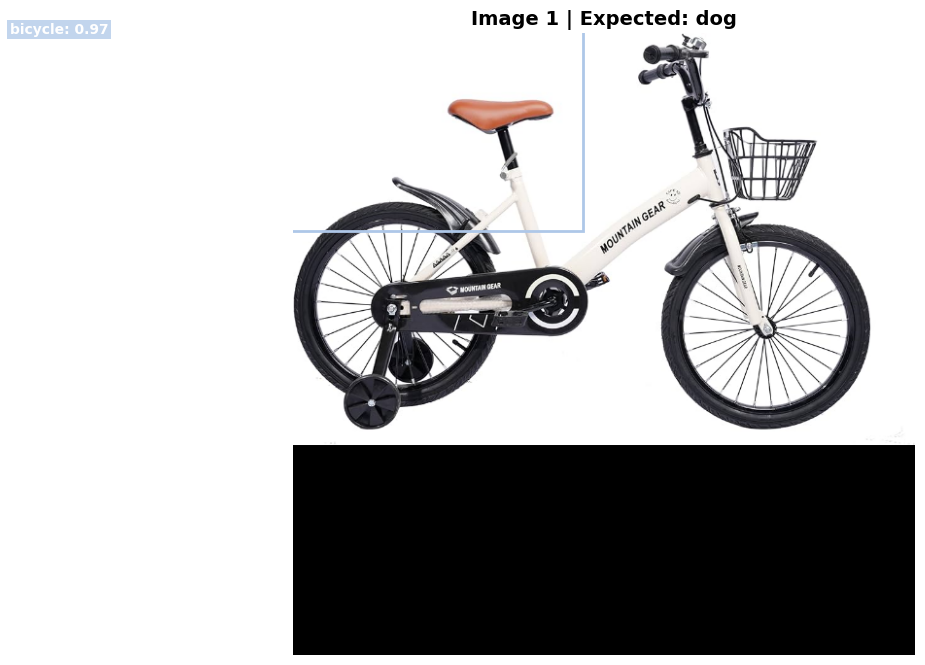

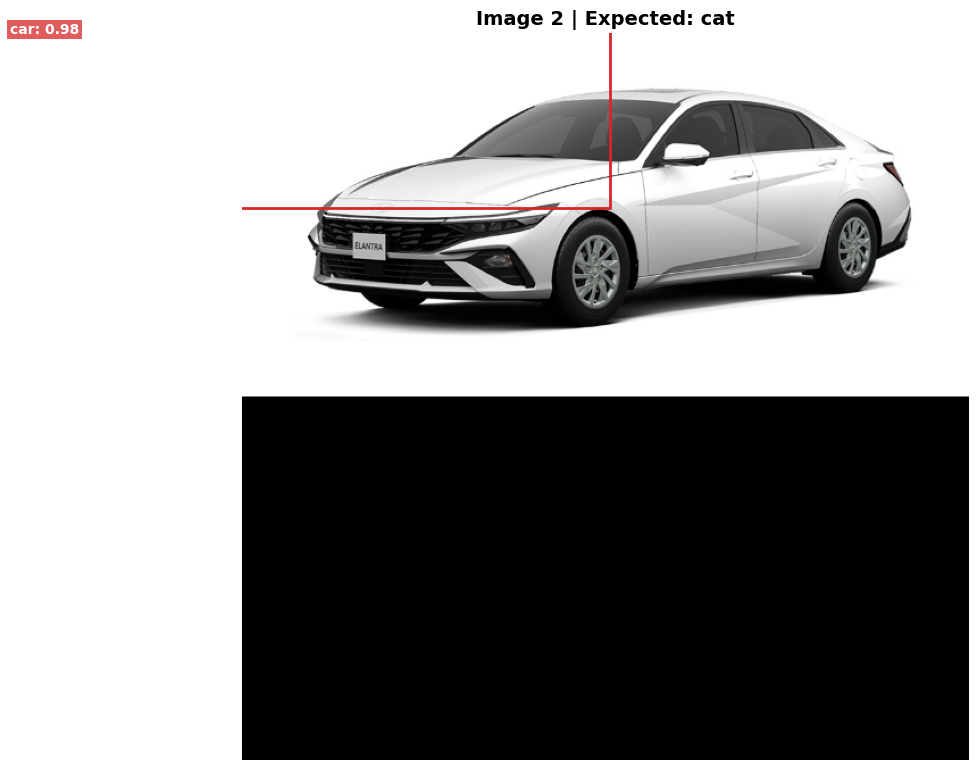

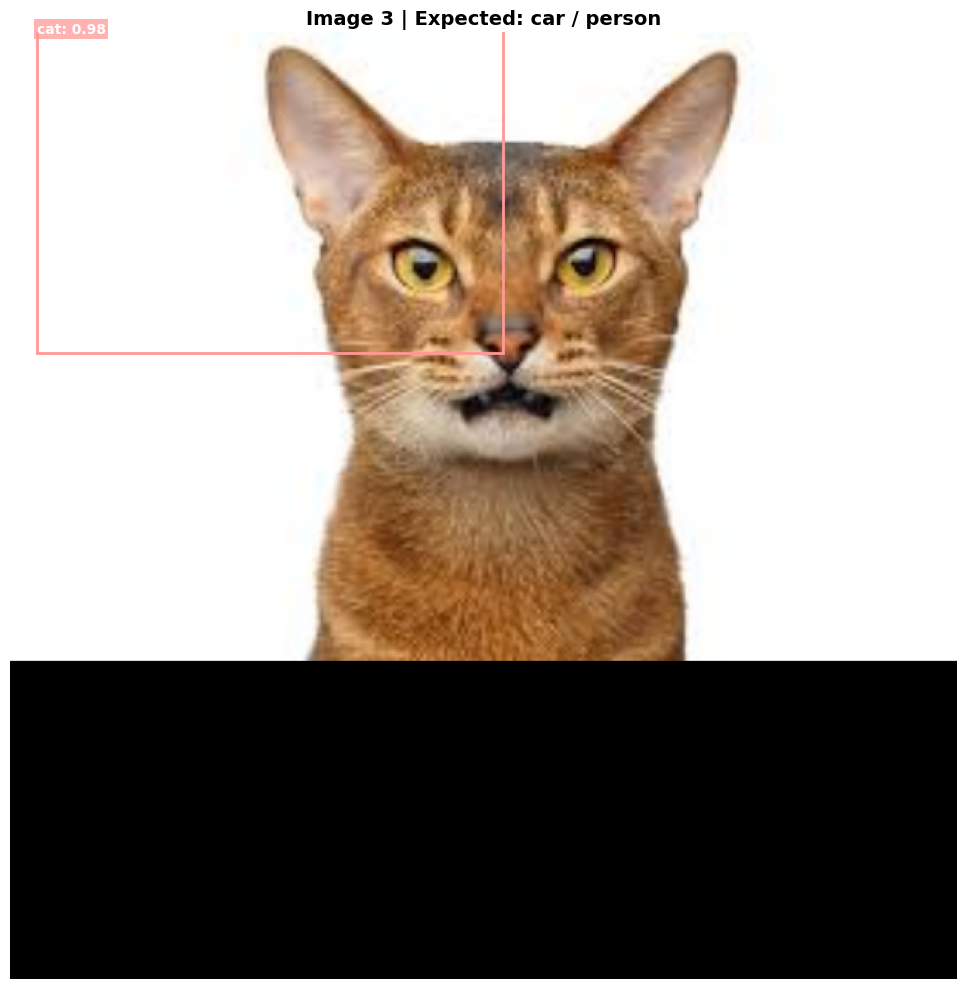

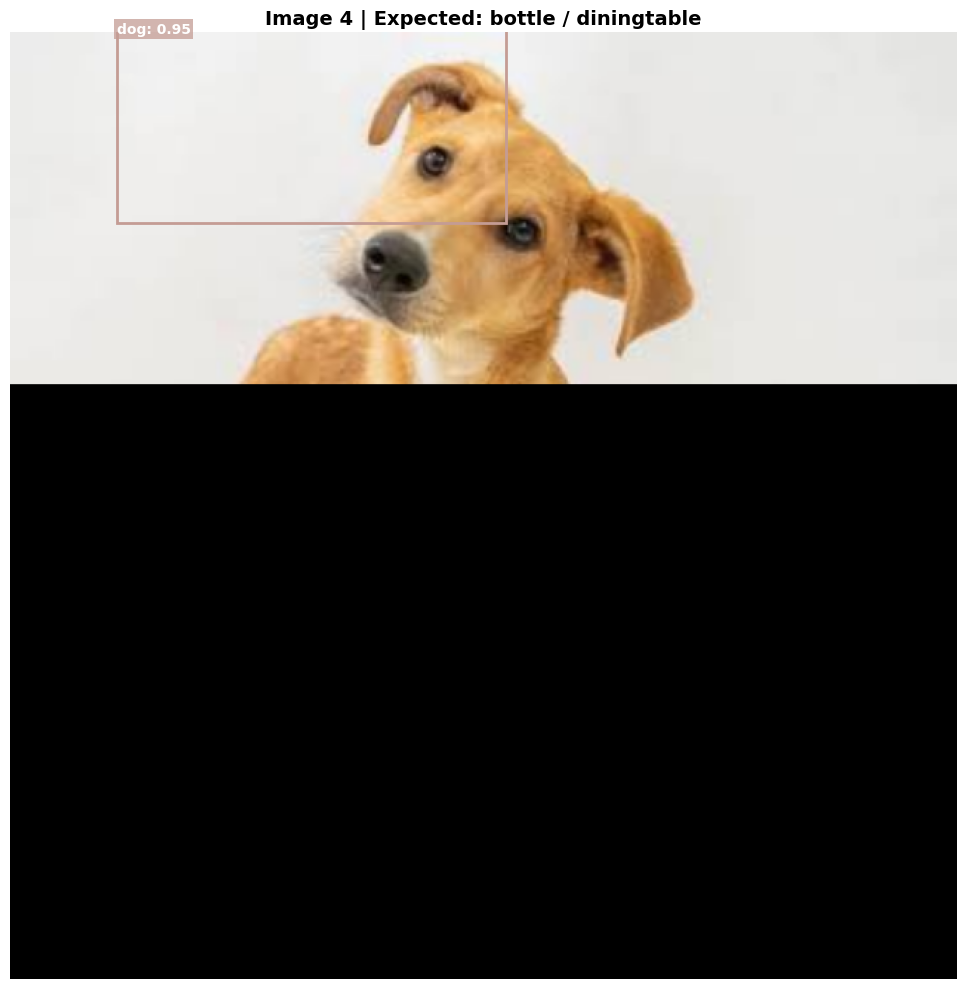

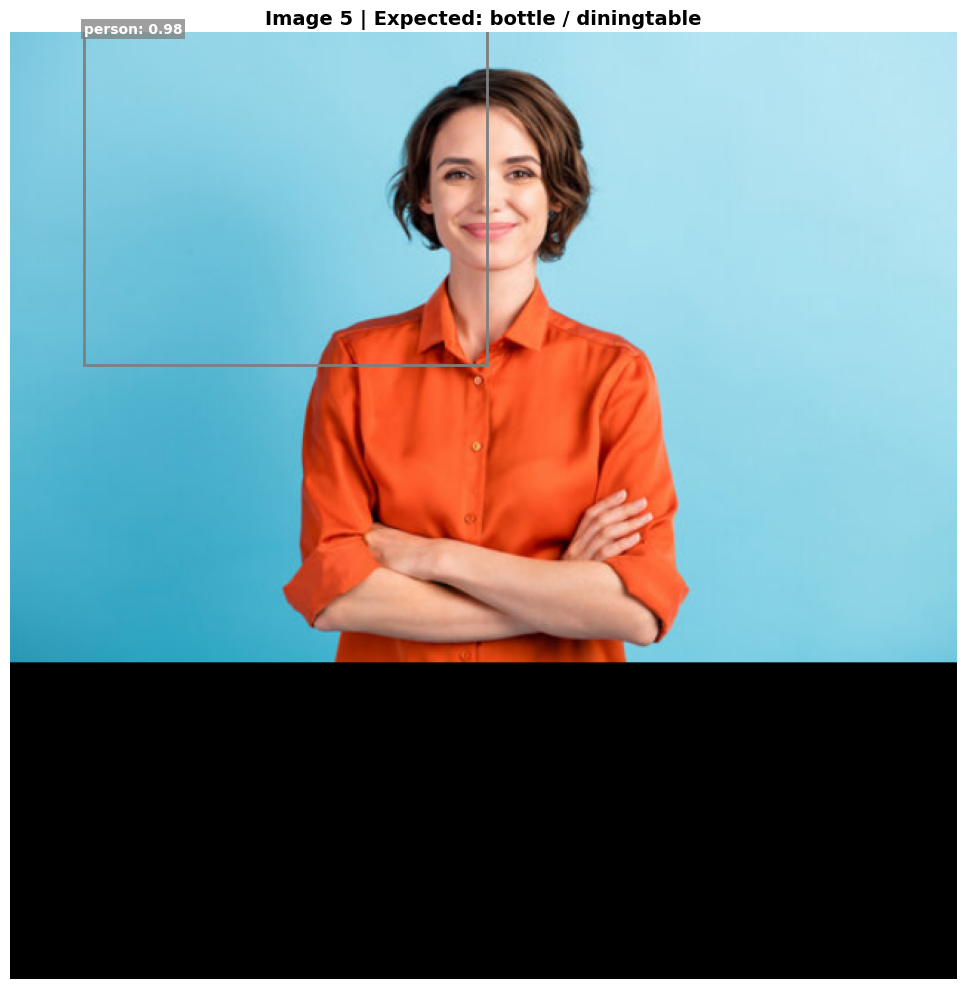

In [24]:
def visualize_detections(image_np, predictions, title='', confidence_threshold=0.5):
    """
    Draw bounding boxes and class labels on a 640x640 image.

    Args:
        image_np     : NumPy array of the resized image (H, W, 3)
        predictions  : dict with keys 'boxes', 'classes', 'confidence', 'num_detections'
        title        : plot title string
        confidence_threshold: minimum confidence to display a detection
    """
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np.astype(np.uint8))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    boxes       = predictions['boxes'][0]
    classes     = predictions['classes'][0]
    confidences = predictions['confidence'][0]
    num_det     = int(predictions['num_detections'][0])

    cmap = plt.cm.get_cmap('tab20', len(VOC_CLASSES))

    for j in range(num_det):
        confidence = float(confidences[j])
        if confidence < confidence_threshold:
            continue

        class_id   = int(classes[j])
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else f'class_{class_id}'
        x_c, y_c, w, h = boxes[j]
        x_min = x_c - w / 2
        y_min = y_c - h / 2

        color = cmap(class_id)
        rect  = patches.Rectangle((x_min, y_min), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        label = f'{class_name}: {confidence:.2f}'
        ax.text(x_min, max(y_min - 5, 0), label,
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.75, pad=2, edgecolor='none'))

    plt.tight_layout()
    plt.show()


# Visualize all 5 images
for i, (img_tensor, preds) in enumerate(zip(resized_images, all_predictions)):
    img_np   = img_tensor[0].numpy()
    expected = image_sources[i]['expected_class']
    title    = f'Image {i+1} | Expected: {expected}'
    visualize_detections(img_np, preds, title=title, confidence_threshold=CONFIDENCE_THRESHOLD)


### Step 9: Detection Summary

For each image, print a structured summary showing:
- Correctly detected objects
- Confidence scores
- Missed objects (expected but not detected)


In [25]:
print('=' * 60)
print('DETECTION SUMMARY')
print('=' * 60)

for i, (src, preds) in enumerate(zip(image_sources, all_predictions)):
    expected    = src['expected_class']
    classes     = preds['classes'][0]
    confidences = preds['confidence'][0]
    num_det     = int(preds['num_detections'][0])

    print(f'\nImage {i+1} | Expected class(es): {expected}')
    print(f'  Total detections (conf >= {CONFIDENCE_THRESHOLD}): {num_det}')

    detected_classes = []
    for j in range(num_det):
        class_id   = int(classes[j])
        class_name = VOC_CLASSES[class_id] if class_id < len(VOC_CLASSES) else f'class_{class_id}'
        confidence = float(confidences[j])
        detected_classes.append((class_name, confidence))
        print(f'    - {class_name}: {confidence:.2f}')

    detected_names  = [c[0] for c in detected_classes]
    expected_list   = [e.strip() for e in expected.split('/')]
    correctly_found = [e for e in expected_list if e in detected_names]
    missed          = [e for e in expected_list if e not in detected_names]

    if correctly_found:
        print(f'  Correctly detected : {correctly_found}')
    if missed:
        print(f'  Missed             : {missed}')
    if not detected_classes:
        print(f'  No objects detected above threshold {CONFIDENCE_THRESHOLD}')

print('\n' + '=' * 60)


DETECTION SUMMARY

Image 1 | Expected class(es): dog
  Total detections (conf >= 0.5): 1
    - bicycle: 0.97
  Missed             : ['dog']

Image 2 | Expected class(es): cat
  Total detections (conf >= 0.5): 1
    - car: 0.98
  Missed             : ['cat']

Image 3 | Expected class(es): car / person
  Total detections (conf >= 0.5): 1
    - cat: 0.98
  Missed             : ['car', 'person']

Image 4 | Expected class(es): bottle / diningtable
  Total detections (conf >= 0.5): 1
    - dog: 0.95
  Missed             : ['bottle', 'diningtable']

Image 5 | Expected class(es): bottle / diningtable
  Total detections (conf >= 0.5): 1
    - person: 0.98
  Missed             : ['bottle', 'diningtable']



### Analysis & Discussion

Reflect on the results above by answering the following questions:

1. **Correct detections** – For which images did YOLOv8 correctly identify the expected object class?

2. **Confidence scores** – How confident was the model in its predictions? Were there any surprising high or low scores?

3. **Missed detections** – Were any expected objects not detected? What might explain this?

4. **False positives** – Were any objects detected that were NOT present in the image?

5. **Effect of resizing** – How does padding during resizing (pad_to_aspect_ratio=True) potentially affect detections near image borders?

6. **YOLOv8 vs Faster R-CNN** – Compare the two approaches based on your observations and the lab notebook:
    - Which architecture is faster at inference?
    - Which tends to produce more accurate or more bounding boxes per image?
    - Which would you choose for a real-time application, and why?

> **Write your observations below** (double-click to edit this cell):

---

**Image 1 (dog):**  


**Image 2 (cat):**  


**Image 3 (car / person):**  


**Image 4 (bottle / diningtable):**  


**Image 5 (bottle / diningtable):**  


**YOLOv8 vs Faster R-CNN comparison:**  

